In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("mexwell/crop-diseases-classification")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'crop-diseases-classification' dataset.
Path to dataset files: /kaggle/input/crop-diseases-classification
Contents of base_path (/kaggle/input):
['crop-diseases-classification']
Contents of path (/kaggle/input/crop-diseases-classification):
['Data']


In [ ]:
import os

# Update path to match 'Data' directory found in the crop diseases dataset
data_path = os.path.join(path, 'Data')

# List subdirectories in Data (usually class labels)
if os.path.exists(data_path):
    print(f"Classes in dataset: {os.listdir(data_path)}")
else:
    print(f"Directory not found: {data_path}")

Classes in dataset: ['label_num_to_disease_map.json', 'train_images', 'train.csv']



--- Sample Images from Dataset (/kaggle/input/crop-diseases-classification/Data) ---
Found 17938 images. Displaying 6 samples:


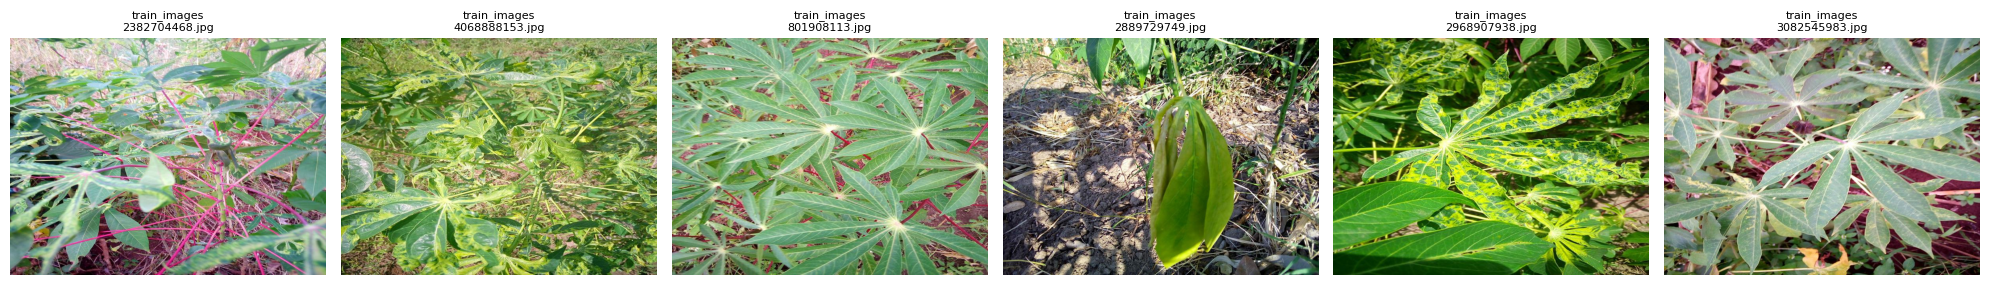

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} samples:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Display class name (parent directory) and filename
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the correct Data path
data_path = os.path.join(path, 'Data')
print(f"\n--- Sample Images from Dataset ({data_path}) ---")
display_sample_images(data_path)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Paths to the CSV file and the image directory
csv_path = os.path.join(data_path, 'train.csv')
image_dir = os.path.join(data_path, 'train_images')

# Read data from CSV
df = pd.read_csv(csv_path)

# Split the dataset into 80% train and 20% test
# stratify=df['label'] ensures the proportion of crop disease classes is maintained in both sets
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"Total samples in 'train_images': {len(df)}")
print(f"Number of training samples: {len(train_df)}")
print(f"Number of test samples: {len(test_df)}")

# Display the first few rows of the training set for verification
display(train_df.head())

Total samples in 'train_images': 21397
Number of training samples: 17117
Number of test samples: 4280


,image_id,label
1715,1300823152.jpg,4
11830,3116613979.jpg,3
8621,2530012971.jpg,3
3849,1686186154.jpg,3
12924,3312736716.jpg,1


In [ ]:
import tensorflow as tf

# Check if GPU is available
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
if tf.config.list_physical_devices('GPU'):
    print("GPU Device Name:", tf.test.gpu_device_name())
else:
    print("Please ensure GPU is enabled in Edit -> Notebook settings.")

Num GPUs Available:  1
GPU Device Name: /device:GPU:0


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define constants
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = df['label'].nunique()

# Data Augmentation and Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Convert 'label' to string for flow_from_dataframe
train_df['label'] = train_df['label'].astype(str)
test_df['label'] = test_df['label'].astype(str)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory=image_dir,
    x_col='image_id',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_dataframe(
    test_df,
    directory=image_dir,
    x_col='image_id',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Build VGG Model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Found 14342 validated image filenames belonging to 5 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 2775 invalid image filename(s) in x_col="image_id". These filename(s) will be ignored.
  warnings.warn(


Found 3596 validated image filenames belonging to 5 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 684 invalid image filename(s) in x_col="image_id". These filename(s) will be ignored.
  warnings.warn(


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,757 (80.64 MB)

 Trainable params: 6,424,069 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Train the model
EPOCHS = 10

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    epochs=EPOCHS
)

Epoch 1/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 345s 735ms/step - accuracy: 0.6084 - loss: 1.1926 - val_accuracy: 0.6119 - val_loss: 0.9410
Epoch 2/10
  1/448 ━━━━━━━━━━━━━━━━━━━━ 1:27 197ms/step - accuracy: 0.5000 - loss: 1.0932

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


448/448 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - accuracy: 0.5000 - loss: 1.0932 - val_accuracy: 0.6119 - val_loss: 0.9388
Epoch 3/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 270s 602ms/step - accuracy: 0.6153 - loss: 1.0354 - val_accuracy: 0.6119 - val_loss: 0.9415
Epoch 4/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - accuracy: 0.6562 - loss: 0.8839 - val_accuracy: 0.6113 - val_loss: 0.9467
Epoch 5/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 269s 600ms/step - accuracy: 0.6157 - loss: 0.9974 - val_accuracy: 0.6119 - val_loss: 0.9577
Epoch 6/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - accuracy: 0.5625 - loss: 1.1476 - val_accuracy: 0.6110 - val_loss: 0.9569
Epoch 7/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 265s 591ms/step - accuracy: 0.6153 - loss: 0.9976 - val_accuracy: 0.6119 - val_loss: 0.9243
Epoch 8/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - accuracy: 0.6562 - loss: 0.9212 - val_accuracy: 0.6119 - val_loss: 0.9265
Epoch 9/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 268s 599ms/step - accuracy: 0.6154 - loss: 0.9889 - val

In [ ]:
# Summarize training results
loss, accuracy = model.evaluate(validation_generator)
print(f"Final Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy:.4f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 31s 275ms/step - accuracy: 0.6121 - loss: 0.9336
Final Validation Loss: 0.9336
Final Validation Accuracy: 0.6121


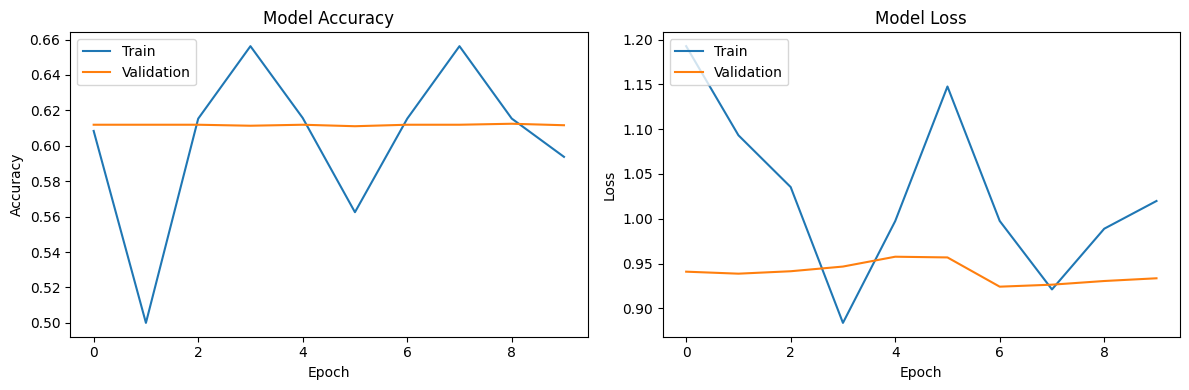

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()